# Assignment 2 — Due 9:00 AM Sunday, 12 April 2026

**Name:** Rawan Mohamed **Student ID:** 202208263

### Submission

In your GitHub repo, under **`assign2`** subfolder:

1. **`tree.pdf`** — all work for Q1.  
2. **This notebook** — run all cells; outputs must be visible.

# Part 1 — Decision Trees (60 pts)

#### **Q1** [30 pts] **Approve Loan**
Build a decision tree **by hand** (paper or drawing tool). Put everything in `tree.pdf`.

- **[24 pts]** At **every** internal node: show the split rule you use, list the candidate splits, and compute the impurity measure (Gini **or** Entropy) for each candidate. Work must be shown step by step.
- **[3 pts]** Final tree diagram: clear structure; each leaf shows the predicted **Approve_Loan** class.
- **[3 pts]** Classify:
  - **A:** Age=Young, Income=High, Own_Home=No, Credit_History=Fair  
  - **B:** Age=Senior, Income=Low, Own_Home=Yes, Credit_History=Poor

| Age       | Income | Own_Home | Credit_History | Approve_Loan |
|-----------|--------|----------|----------------|--------------|
| Young     | High   | Yes      | Good           | Yes          |
| Young     | High   | No       | Good           | No           |
| Middle    | High   | Yes      | Good           | Yes          |
| Senior    | Medium | No       | Good           | Yes          |
| Senior    | Low    | Yes      | Fair           | Yes          |
| Senior    | Low    | No       | Fair           | No           |
| Middle    | Low    | Yes      | Fair           | Yes          |
| Young     | Medium | No       | Fair           | No           |
| Young     | Low    | Yes      | Good           | Yes          |
| Senior    | Medium | Yes      | Fair           | Yes          |
| Young     | Medium | Yes      | Poor           | No           |
| Middle    | Medium | No       | Good           | Yes          |
| Middle    | High   | Yes      | Poor           | Yes          |
| Senior    | Medium | No       | Poor           | No           |
| Young     | Low    | No       | Poor           | No           |

#### **Q2** [5 pts] Load `loan_dataset.csv` into a Pandas DataFrame and preprocess it. Prepare feature matrix and target so a `sklearn` decision tree can be trained.

- **[2 pts]** Encode the target variable using `LabelEncoder`.
- **[3 pts]** Encode the features using `OneHotEncoder` (set `sparse_output=False`).
- Display the first 5 rows of the preprocessed features and target.

In [17]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [18]:
# Your code here

loans = pd.read_csv('loan_dataset.csv')
label_encoder = LabelEncoder()
one_hot_encoder = OneHotEncoder(sparse_output=False)
loans["Approve_Loan"] = label_encoder.fit_transform(loans["Approve_Loan"])
# loans[["Age", "Income", "Own_Home", "Credit_History"]] = one_hot_encoder.fit_transform(loans[["Age", "Income", "Own_Home", "Credit_History"]]) => wrong because when we do one hot encoding, we get more columns than the original ones, so we can't assign it back to the original columns
encoded_features = one_hot_encoder.fit_transform(loans[["Age", "Income", "Own_Home", "Credit_History"]])
encoded_features_df = pd.DataFrame(encoded_features, columns=one_hot_encoder.get_feature_names_out(["Age", "Income", "Own_Home", "Credit_History"]))
loans = pd.concat([loans.drop(columns=["Age", "Income", "Own_Home", "Credit_History"]), encoded_features_df], axis=1)
x = loans.drop(columns=["Approve_Loan"])
y = loans["Approve_Loan"]
loans.head(5)


,Approve_Loan,Age_Middle,Age_Senior,Age_Young,Income_High,Income_Low,Income_Medium,Own_Home_No,Own_Home_Yes,Credit_History_Fair,Credit_History_Good,Credit_History_Poor
0,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
1,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
2,0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
3,1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0


#### **Q3** [4 pts] Train and evaluate a Decision Tree classifier.

- **[1 pt]** Split the data into 80% training / 20% testing (`random_state=42`).
- **[1 pt]** Train a Decision Tree Classifier with default parameters.
- **[1 pt]** Visualize the trained tree.
- **[1 pt]** Report the training accuracy and testing accuracy.

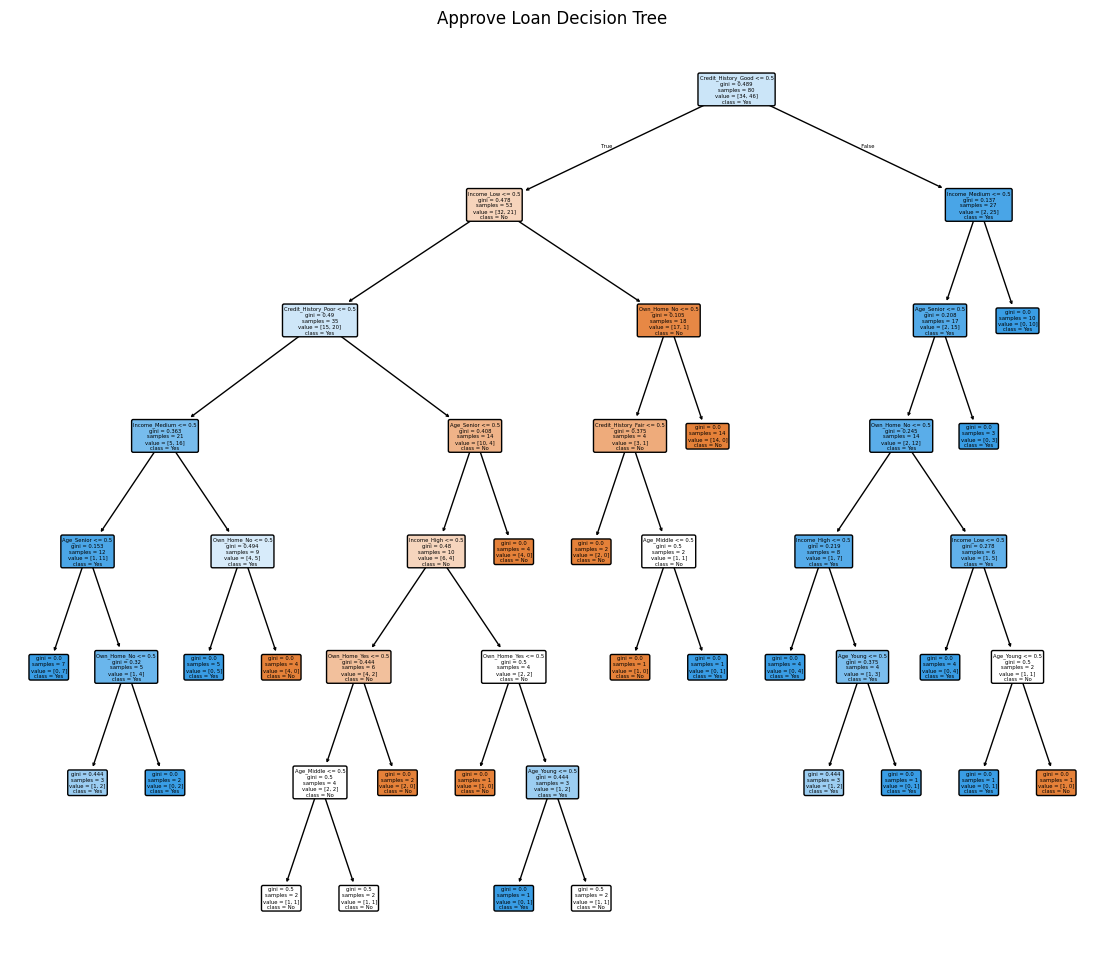

Train data accuracy (using .score method): 0.9375
Test data accuracy (using .score method): 0.9


In [19]:
# Your code here

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

tree = DecisionTreeClassifier(random_state=42)
tree.fit(x_train, y_train)

plt.figure(figsize=(14, 12))
plot_tree(
    tree,
    feature_names=x.columns,
    class_names=label_encoder.classes_,
    filled=True,
    rounded=True
)
plt.title("Approve Loan Decision Tree")
plt.show()

print("Train data accuracy (using .score method):", tree.score(x_train, y_train))
print("Test data accuracy (using .score method):", tree.score(x_test, y_test))



#### **Q4** [6 pts] **Test-set evaluation** (same model as Q3)

- **[1 pt]** Display Confusion matrix.
- **[1 pt]** Classification report (precision, recall, F1 per class).
- **[4 pts]** In a markdown below the code: Which class is harder to predict, and why? Is the model overfitting? Support your answers with the numbers you produced.

[[10  2]
 [ 0  8]]


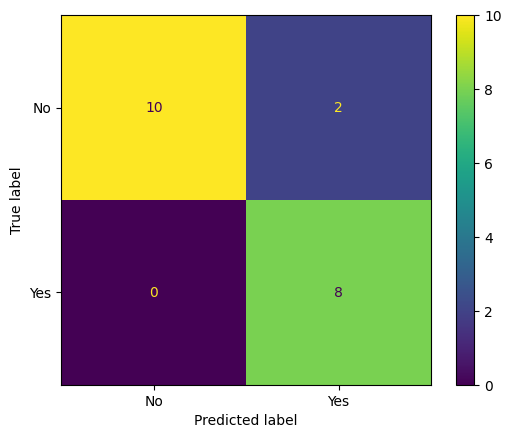

              precision    recall  f1-score   support

          No       1.00      0.83      0.91        12
         Yes       0.80      1.00      0.89         8

    accuracy                           0.90        20
   macro avg       0.90      0.92      0.90        20
weighted avg       0.92      0.90      0.90        20



In [21]:
# Your code here
y_true = y_test
y_pred = tree.predict(x_test)

cm = confusion_matrix(y_true, y_pred)
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot()
plt.show()

print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))


*Which class is harder to predict, and why?*
- The No class is harder to predict as is it predicted a yes two times when it was actually no, while it never predicted a no for when it was a yes. This is further proven by the recall values for the No and Yes classes, yes has a 1 recall which means 0 have been misclassified, while No has 0.83 showing the 2 cases where it has been misclassified.

*Is the model overfitting?*
- the model is not overfitting as the difference between test accuracy and training accuracy is only about 4%, with the test accuracy being 90% while training accuracy about 94%. this shows that the model generalizes well to unseen data.

#### **Q5** [7 pts] Investigate the effect of tree depth on generalization.

- **[3 pts]** Train Decision Tree Classifier models with `max_depth` ∈ {2, 4, 6, 8, None}. Record the training and testing accuracy for each.
- **[2 pts]** Plot both curves (training & testing accuracy vs. max_depth) on the same graph with labels and legend.
- **[2 pts]** In markdown cell, which depth best balances bias and variance for this data? Explain using the curves.

In [ ]:
# Your code here


#### **Q6** [8 pts] Train and compare a Random Forest model.

- **[4 pts]** Train a Random Forest Classifier. Experiment with `n_estimators` ∈ {50, 100, 200} and `max_features` ∈ {'sqrt', 'log2'}. Report the best combination based on test accuracy.
- **[2 pts]** Run 5-fold cross-validation on the best Random Forest. Report the fold accuracies, mean, and standard deviation.
- **[2 pts]** In markdpwn cell, compare the Random Forest to the best Decision Tree from Q5. Which generalizes better and why?

In [ ]:
# Your code here


---

# Part 2 — kNN (40 pts)

Explore how different hyperparameters affect kNN classifier performance. You will:
1. Split data into training, validation, and testing sets.
2. Compare distance metrics: Euclidean (L2) vs. Manhattan (L1).
3. Perform a grid search over k and the distance metric to find optimal hyperparameters.
4. Evaluate the final tuned model on unseen data.

## Data (provided)

Run the next cells to build the **two circles** data (with extra noisy structure). Do not change the generation code.

In [ ]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import make_circles

In [ ]:
X, y = make_circles(n_samples=1000, noise=0.15, factor=0.5, random_state=37)

np.random.seed(21)
X_aug = X.tolist()
y_aug = y.tolist()

n_clusters = 15

for _ in range(n_clusters):
    idx = np.random.randint(0, len(X))
    base_point = X[idx]
    base_label = y[idx]

    new_label = 1 - base_label

    n_new_points = np.random.randint(5, 9)

    for _ in range(n_new_points):
        new_point = base_point + np.random.normal(scale=0.15, size=2)
        X_aug.append(new_point)
        y_aug.append(new_label)

X_aug = np.array(X_aug)
y_aug = np.array(y_aug)

print("Original dataset size:", X.shape[0])
print("Augmented dataset size:", X_aug.shape[0])

## Visualize (run cell; figure provided)

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(X_aug[y_aug == 0, 0], X_aug[y_aug == 0, 1],
            c='steelblue', label='Class 0', alpha=0.6, edgecolors='k', linewidths=0.3, s=20)
plt.scatter(X_aug[y_aug == 1, 0], X_aug[y_aug == 1, 1],
            c='coral', label='Class 1', alpha=0.6, edgecolors='k', linewidths=0.3, s=20)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Two Circles Dataset (Augmented with Noise)')
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()


## Step 1 [3 pts] — Split the Dataset
Split the data into **three** sets:
- **70%** Training
- **15%** Validation
- **15%** Testing

Use `random_state=42` for all splits. Print the shapes to verify.

In [ ]:
# Your code here


## Step 2 [3 pts] — Baseline Euclidean

- **[2 pts]** Train a kNN classifier with `n_neighbors=5` and `p=2` (Euclidean).
- **[1 pt]** Predict on the **test** set. Print the accuracy.

In [ ]:
# Your code here


## Step 3 [3 pts] — kNN with k=5 and Manhattan Distance
- **[1 pt]** Train a kNN classifier with `n_neighbors=5` and `p=1` (Manhattan).
- **[1 pt]** Predict on the **test** set. Print the accuracy.
- **[1 pt]** In Markdown cell, compare results with step 2 and interpret.

In [ ]:
# Your code here


## Step 4 [10 pts] — Hyperparameter Tuning using Grid Search
- **[6 pts]** Perform a grid search over the **validation set** to find the best combination of:\
`k` ∈ {1, 3, 5, 7, 9, 11, 15, 21, 31, 41, 51} \
`p` ∈ {1, 2} &nbsp;(Manhattan vs. Euclidean) 

- **[2 pts]** Store the per-k accuracies for each distance metric (needed for Step 5).
- **[2 pts]** Identify and print the **best (k, p)** combination and its validation accuracy.


In [ ]:
# Your code here


## Step 5 [9 pts] — Visualization of Accuracy vs. k
- **[4 pts]** Plot validation accuracy as a function of k with **two curves** on the same plot: \
One for Euclidean (`p=2`) \
One for Manhattan (`p=1`)
- **[1 pt]** Include a legend, axis labels, and a descriptive title.
- **[4 pts]** In a markdown cell below your plot, describe the bias-variance behavior you observe as k increases.

In [ ]:
# Your code here


## Step 6 [12 pts] — Final model

Using the best `(k, distance)` from Step 4.

- **[2 pts]** Retrain the model on the full training data (training + validation combined).
- **[2 pts]** Evaluate on the held-out test set and print the final test accuracy.
- **[2 pts]** Print the full classification report on the test set.
- **[2 pts]** In Markdown cell: which class is harder to predict, and what does that suggest about your chosen `k`?
- **[4 pts]** In Markdown cell: compare the final model accuracy vs. Steps 2 and 3. Did hyperparameter tuning improve performance? Explain Why or why not?

In [ ]:
# Your code here
